In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# A made-up samples
X_train = np.array([[18, 10, 0],
                    [16, 7, 1],
                    [26, 6, 0],
                    [14, 10, 1],
                    [11, 10, 1],
                    [21, 5, 0],
                    [13, 10, 0],
                    [10, 8, 0],
                    [10, 10, 0],
                    [9, 10, 1],
                    [9, 8, 1],
                    [17, 5, 0],
                    [16, 6, 0],
                    [16, 4, 0],
                    [40, 10, 0],
                    [35, 9, 1],
                    ],
                   )

X_train = np.tile(X_train, (1000, 1))
y_train = np.array([50000, 12000, 23000, 45000, 68000, 20000, 88000,
                   90000, 150000, 130000, 85000, 15000, 23000, 11000, 35000, 15000]) / 10000
y_train = np.tile(y_train, 1000)

In [3]:
def fx(X, w, b):
    return np.dot(X, w) + b

In [4]:
def compute_cost(X, y, w, b):
    m = len(X_train)
    f_wb = fx(X, w, b)
    loss = (f_wb - y) ** 2
    cost = 1 / m * np.sum(loss)
    return cost

In [5]:
def compute_gradient(X, y, w, b):
    m = X.shape[0]
    f_wb = fx(X, w, b)
    dj_dw = np.sum((f_wb - y).reshape(-1, 1) * X, axis=0) / m
    dj_db = np.sum((f_wb - y)) / m

    return dj_dw, dj_db

In [6]:
def compute_gradient_descent(X, y, alpha=4e-3, n_iter=5000):
    w = np.ones_like(X_train[0], dtype=float)
    b = 0.0

    for _ in range(n_iter):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

    return w, b

In [7]:
final_w, final_b = compute_gradient_descent(X_train, y_train)
cost = compute_cost(X_train, y_train, final_w, final_b)
print("Cost:", cost)
print("Final w:", final_w)
print("Final b:", final_b)


Cost: 4.757566055683208
Final w: [-0.28116717  1.36851687 -2.12351796]
Final b: 0.16071222256800824


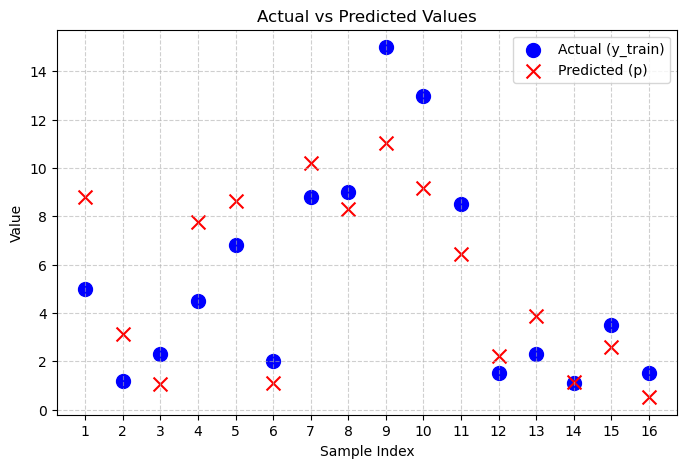

In [8]:
actual_sample_size = 16
predictions = []
actual_values = []

for i, x in enumerate(X_train[:actual_sample_size]):
    pred = fx(x, final_w, final_b)
    predictions.append(pred)
    actual_values.append(y_train[i])

plt.figure(figsize=(8, 5))
sample_indices = range(1, actual_sample_size + 1)

plt.scatter(sample_indices, actual_values, color='blue',
            label='Actual (y_train)', marker='o', s=100)
plt.scatter(sample_indices, predictions, color='red',
            label='Predicted (p)', marker='x', s=100)

plt.title('Actual vs Predicted Values')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.xticks(sample_indices)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

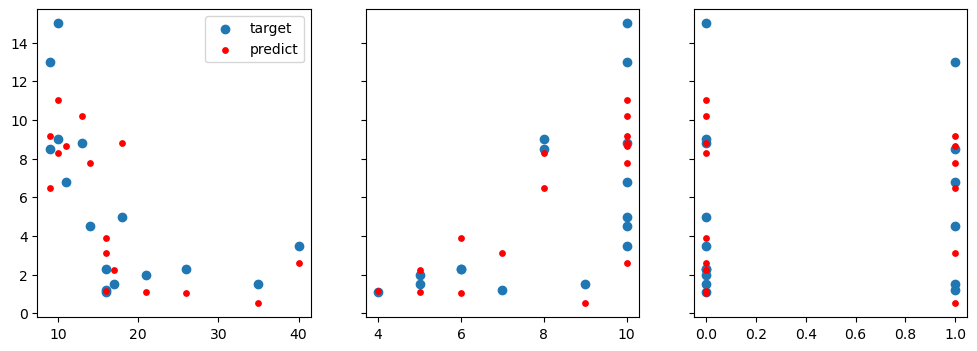

In [9]:
plt.close()
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:actual_sample_size, i], y_train[:actual_sample_size], label='target')
    ax[i].scatter(X_train[:actual_sample_size, i], predictions, color='r', label='predict', marker='.', s=60)
ax[0].legend()